In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.constants import Avogadro

hexcolors = [
    '#D1B8D7', '#AE76A3', '#882E72',
    '#1965B0', '#5289C7', '#7BAFDE',
    '#4EB265', '#90C987', '#CAE0AB',
    '#F7F056', '#F6C141', '#F1932D',
    '#E8601C', '#DC050C', '#777777'
]
 
colornames = [
    'purple1','purple2','purple3',
    'blue1','blue2','blue3',
    'green1','green2','green3',
    'yellow1','yellow2','orange1',
    'orange2','red','grey'
]
 
rnb_colors = dict(zip(colornames, hexcolors))

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial'] + plt.rcParams['font.sans-serif']
mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Times New Roman'
mpl.rcParams['mathtext.it'] = 'Times New Roman:italic'
mpl.rc('pdf', fonttype=42)

In [2]:
def plot_avg_conc_profile(ax,system,protein,first,n_mols,bin_width,color):
    concs = []
    for j in range(5):
        d = np.empty(0)
        for i in range(first,first+n_mols):
                z = np.load(f'data/LAT_Grb2_Sos1/{system}_{j}_{protein}_{i}_com_z.npy')
                d = np.append(d, z)
        
        n_frames = d.size / n_mols

        bins = np.arange(-75, 75+bin_width, bin_width)
        x = bins[:-1] + bin_width/2.
        h = np.histogram(d, bins=bins)[0]

        lx = np.load(f'data/LAT_Grb2_Sos1/{system}_{j}_lx.npy').mean()
        area = lx*lx

        slice_volume = area*bin_width*1e-24

        concs.append(h / n_frames / Avogadro / slice_volume * 1e6)
        
    conc_avg = np.mean(concs,axis=0)/1e3
    conc_std = np.std(concs,axis=0)/1e3

    if protein[-3:] == 'LAT':
        ax.plot(x, conc_avg, color=rnb_colors[color],label=protein)
    else:
        ax.plot(x, conc_avg, color=rnb_colors[color])
    ax.fill_between(x, conc_avg-conc_std, conc_avg+conc_std, color=rnb_colors[color],
                   alpha=0.5, lw=0)
    ax.set_ylabel(f'[{protein}] / mM')
    ax.set_xlabel('$z_\mathrm{COM}$ / nm')
    ax.set_xlim(-75,75)
    ax.set_xticks([-75,-50,-25,0,25,50,75])
    ax.set_ylim(0,)
    if protein[-3:] == 'LAT':
        ax.legend(frameon=False,handlelength=1.5)

def plot_avg_contact_profile(ax,system,xlabel,avgdir,protein_1,protein_2,n_mols,color):
    cmap = []
    for j in range(5):
        arr = np.load(f'data/LAT_Grb2_Sos1/{system}_{j}_{protein_1}_{protein_2}_cmap.npy')
        cmap.append(arr)
    cmap_mean = np.mean(cmap,axis=0)
    cmap_err = np.std(cmap,axis=0)/np.sqrt(5)

    resid = np.arange(cmap_mean.shape[int(np.abs(avgdir-1))])+1
    ax.plot(resid,cmap_mean.sum(axis=avgdir),color=rnb_colors[color])
    ax.fill_between(resid,cmap_mean.sum(axis=avgdir)-cmap_err.sum(axis=avgdir),
                    cmap_mean.sum(axis=avgdir)+cmap_err.sum(axis=avgdir),
                     alpha=.5,lw=0,color=rnb_colors[color])
    ax.set_xlim(resid[0],resid[-1])
    ax.set_xlabel(xlabel+' residues')
    return cmap_mean

def calc_delta_n(system,protein,replica,first,n_mols):
    n_frames = np.load(f'data/LAT_Grb2_Sos1/{system}_{replica}_{protein}_{first}_com_z.npy').size
    n_pos = np.zeros(n_frames)
    n_neg = np.zeros(n_frames)

    for i in range(first, first + n_mols):
        z = np.load(f'data/LAT_Grb2_Sos1/{system}_{replica}_{protein}_{i}_com_z.npy')
        n_pos += np.logical_and(z > 0, z < 20)
        n_neg += np.logical_and(z < 0, z > -20)

    return (n_neg - n_pos)

LAT_Grb2_Sos1 0.9943333333333333 0.16754003759558747
pLAT_Grb2_Sos1 3.510666666666667 0.3279292832529826
460.0243684169277 16.64128187083164
762.6025097284862 19.161738085616584


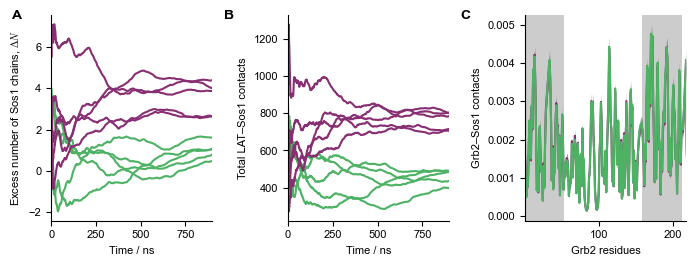

In [7]:
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial'], 'size': 8})

fig, (ax1,ax2,ax3) = plt.subplots(1, 3, figsize=(7, 2.7), sharex=False)

time = 0.5 * np.arange(1, 1800 + 1)

system = 'LAT_Grb2_Sos1'
fraction = []
for j in range(5):
    y = calc_delta_n(system,'Sos1',j,48,32)
    time = 0.5 * np.arange(1, y.size + 1)
    ax1.plot(time,np.cumsum(y)/np.arange(1,y.size+1),color=rnb_colors['green1'])
    fraction.append(y.mean())
print(system,np.mean(fraction),np.std(fraction)/np.sqrt(len(fraction)))
system = 'pLAT_Grb2_Sos1'
fraction = []
for j in range(5):
    y = calc_delta_n(system,'Sos1',j,48,32)
    time = 0.5 * np.arange(1, y.size + 1)
    ax1.plot(time,np.cumsum(y)/np.arange(1,y.size+1),color=rnb_colors['purple3'])
    fraction.append(y.mean())
print(system,np.mean(fraction),np.std(fraction)/np.sqrt(len(fraction)))

ax1.set_xlabel('Time / ns')
ax1.set_ylabel('Excess number of Sos1 chains, $\Delta N$')

system = 'LAT_Grb2_Sos1'
contacts = []
for j in range(5):
    y = np.load(f'data/LAT_Grb2_Sos1/{system}_{j}_LAT_Sos1_contacts.npy')
    time = 0.5 * np.arange(1, y.size + 1)
    ax2.plot(time,np.cumsum(y)/np.arange(1,y.size+1),color=rnb_colors['green1'])
    contacts.append(y.mean())
print(np.mean(contacts),np.std(contacts)/np.sqrt(len(contacts)))
system = 'pLAT_Grb2_Sos1'
contacts = []
for j in range(5):
    y = np.load(f'data/LAT_Grb2_Sos1/{system}_{j}_pLAT_Sos1_contacts.npy')
    time = 0.5 * np.arange(1, y.size + 1)
    ax2.plot(time,np.cumsum(y)/np.arange(1,y.size+1),color=rnb_colors['purple3'])
    contacts.append(y.mean())
print(np.mean(contacts),np.std(contacts)/np.sqrt(len(contacts)))

ax2.set_xlabel('Time / ns')
ax2.set_ylabel('Total LAT–Sos1 contacts')

plot_avg_contact_profile(ax3,'pLAT_Grb2_Sos1','Grb2',1,'Grb2','Sos1',[16,32],'purple3')
plot_avg_contact_profile(ax3,'LAT_Grb2_Sos1','Grb2',1,'Grb2','Sos1',[16,32],'green1')
ax3.set_ylabel('Grb2–Sos1 contacts')

for ax in [ax1,ax2,ax3]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax1.annotate('A', (-0.24, .98), xycoords='axes fraction', fontsize=10, fontweight='bold')
ax2.annotate('B', (-0.4, .98), xycoords='axes fraction', fontsize=10, fontweight='bold')
ax3.annotate('C', (-0.4, .98), xycoords='axes fraction', fontsize=10, fontweight='bold')

ax3.axvspan(1,54,color='k',alpha=.2,lw=0)
ax3.axvspan(158,211,color='k',alpha=.2,lw=0)

ax1.set_xlim(0,900)
ax2.set_xlim(0,900)
ax3.set_xlim(1,217)

plt.tight_layout()
plt.savefig('figS19.pdf')
plt.show()

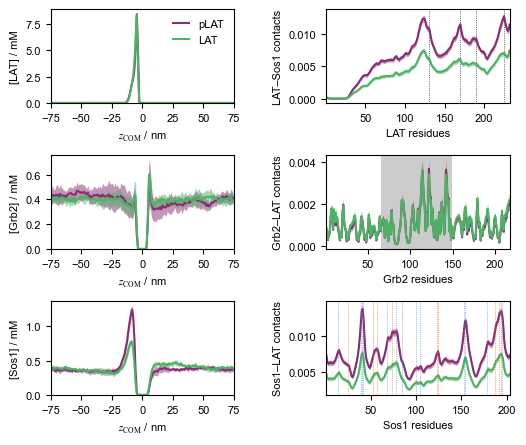

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(5.3, 4.5), sharex=False, sharey=False)
plt.rc('font', **{'family':'sans-serif','sans-serif':['Arial'], 'size': 8})

bin_width = 1

for ax, first, n_mols, protein in zip(axes[:,0], [0,16,48], [16,32,32], ['pLAT','Grb2','Sos1']):
    plot_avg_conc_profile(ax,'pLAT_Grb2_Sos1',protein,first,n_mols,bin_width,'purple3')
for ax, first, n_mols, protein in zip(axes[:,0], [0,16,48], [16,32,32], ['LAT','Grb2','Sos1']):
    plot_avg_conc_profile(ax,'LAT_Grb2_Sos1',protein,first,n_mols,bin_width,'green1')

for resid_ptyr in [131, 170, 190, 225]:
    axes[0,1].axvline(resid_ptyr,color='k',lw=.5,ls=':')
    
plot_avg_contact_profile(axes[0,1],'pLAT_Grb2_Sos1','LAT',1,'pLAT','Sos1',[16,32],'purple3')
plot_avg_contact_profile(axes[1,1],'pLAT_Grb2_Sos1','Grb2',0,'pLAT','Grb2',[16,32],'purple3')
plot_avg_contact_profile(axes[2,1],'pLAT_Grb2_Sos1','Sos1',0,'pLAT','Sos1',[16,32],'purple3')
plot_avg_contact_profile(axes[0,1],'LAT_Grb2_Sos1','LAT',1,'LAT','Sos1',[16,32],'green1')
plot_avg_contact_profile(axes[1,1],'LAT_Grb2_Sos1','Grb2',0,'LAT','Grb2',[16,32],'green1')
plot_avg_contact_profile(axes[2,1],'LAT_Grb2_Sos1','Sos1',0,'LAT','Sos1',[16,32],'green1')
 
axes[0,1].set_ylabel('LAT–Sos1 contacts')

axes[1,1].axvspan(66,149,color='k',alpha=.2,lw=0)

axes[1,1].set_ylabel('Grb2–LAT contacts')

for resid_lys in [25,  53,  57,  73, 123, 124, 187, 191, 194]:
    axes[2,1].axvline(resid_lys,color=rnb_colors['orange2'],lw=.5,ls=':')
    
for resid_arg in [14,  39,  40,  41,  68,  78,  84, 100, 104, 153, 154, 178, 195]:
    axes[2,1].axvline(resid_arg,color=rnb_colors['blue2'],lw=.5,ls=':')

axes[2,1].set_ylabel('Sos1–LAT contacts')

plt.tight_layout(w_pad=3)
plt.savefig('fig6.pdf')
plt.show()